In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.use('Agg')
sns.set_theme(style="whitegrid",palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'

df=pd.read_csv(r"C:\Users\pc\Desktop\fraud detection project\fraud_merged.csv")
print("Fraud rate:", round(df['isFraud'].mean()*100, 2), "%")

df.shape


Fraud rate: 3.5 %


(590540, 434)

In [79]:
%matplotlib inline
import matplotlib.pyplot as plt


In [80]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


averall fraud distribution 
establishes your baseline and shows class imbalance 

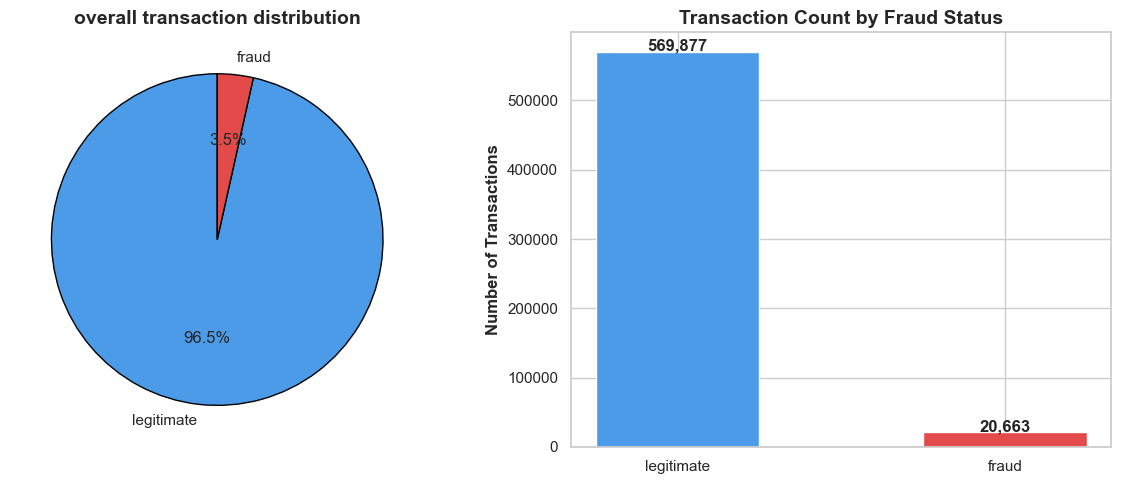


Legitimate: 569,877 (96.50%)
Fraud:      20,663 (3.50%)


In [81]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct=df['isFraud'].value_counts(normalize=True) * 100
fig,axes =plt.subplots(1,2,figsize=(12,5))
axes[0].pie(
    fraud_counts,
    labels=['legitimate','fraud'],
    autopct='%1.1f%%',
    colors=['#4C9BE8', '#E24B4A'],
    startangle=90,
    wedgeprops={'edgecolor':'black','linewidth':1}
)
axes[0].set_title('overall transaction distribution')
#bar chart
bars=axes[1].bar(['legitimate','fraud'],
                fraud_counts.values,
                color=['#4C9BE8', '#E24B4A'],
    edgecolor='white', width=0.5
                )
for bar, count in zip(bars, fraud_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,f'{count:,}', ha='center', fontweight='bold')
axes[1].set_title('Transaction Count by Fraud Status')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.savefig('fraud_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLegitimate: {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraud:      {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")

Transaction Amount Distribution
# Why: Shows fraud amount patterns — card testing vs big hits

C:\Users\pc\AppData\Local\Temp\ipykernel_19924\1761002957.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


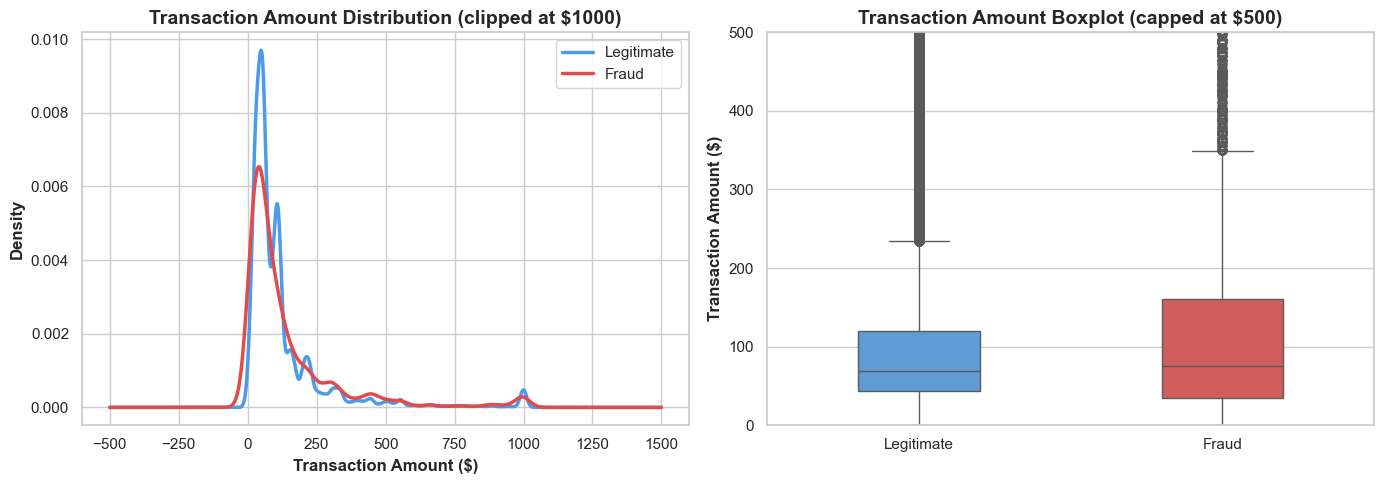

In [82]:
fraud = df[df['isFraud'] == 1]
legit = df[df['isFraud'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE comparison — raw amounts
legit['TransactionAmt'].clip(upper=1000).plot.kde(
    ax=axes[0], color='#4C9BE8', linewidth=2.5, label='Legitimate'
)
fraud['TransactionAmt'].clip(upper=1000).plot.kde(
    ax=axes[0], color='#E24B4A', linewidth=2.5, label='Fraud'
)
axes[0].set_title('Transaction Amount Distribution (clipped at $1000)')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].legend()

# Boxplot comparison
df_plot = df[['isFraud', 'TransactionAmt']].copy()
df_plot['label'] = df_plot['isFraud'].map({0: 'Legitimate', 1: 'Fraud'})
sns.boxplot(
    data=df_plot, x='label', y='TransactionAmt',
    palette={'Legitimate': '#4C9BE8', 'Fraud': '#E24B4A'},
    ax=axes[1], width=0.4
)
axes[1].set_ylim(0, 500)
axes[1].set_title('Transaction Amount Boxplot (capped at $500)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Transaction Amount ($)')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [83]:
print(f"Median amount — Legitimate: ${legit['TransactionAmt'].median():.2f}")
print(f"Median amount — Fraud:      ${fraud['TransactionAmt'].median():.2f}")
print(f"\nMin fraud amount:  ${fraud['TransactionAmt'].min():.2f} (card testing)")
print(f"Max fraud amount:  ${fraud['TransactionAmt'].max():.2f} (big hit)")

Median amount — Legitimate: $68.50
Median amount — Fraud:      $75.00

Min fraud amount:  $0.29 (card testing)
Max fraud amount:  $5191.00 (big hit)


Log-Scale Amount Distribution
# Why: Financial data is right-skewed — log transform reveals patterns

In [84]:
df['log_amt'] = np.log1p(df['TransactionAmt'])

legit = df[df['isFraud'] == 0]
fraud = df[df['isFraud'] == 1]

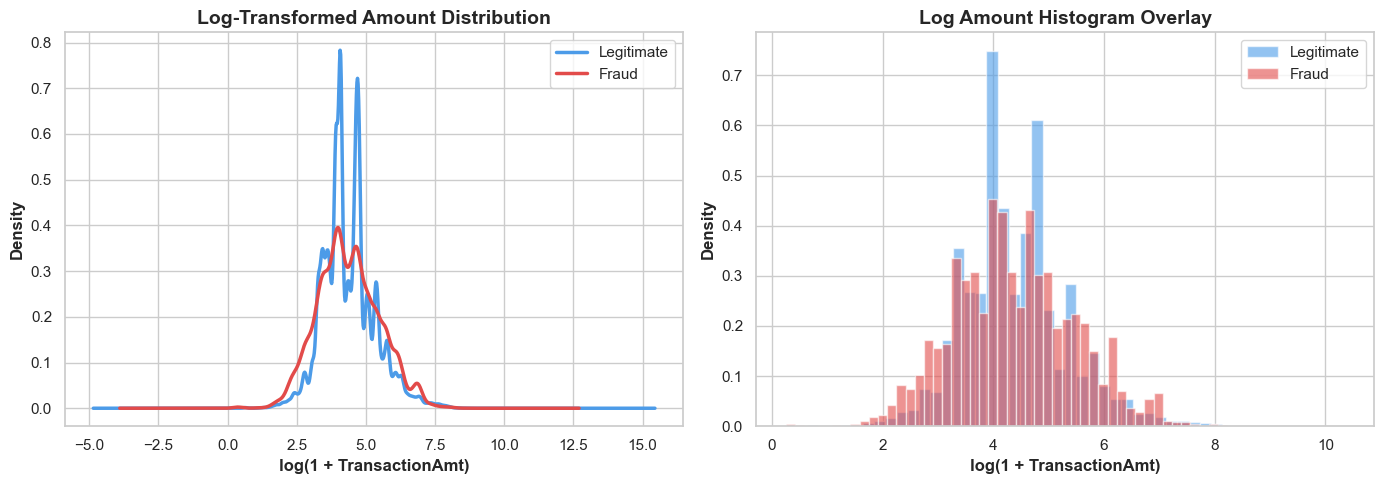

Log transformation applied — this becomes 'log_amt' feature in Phase 3
Fraud shows a different distribution peak — log_amt is a useful feature


In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log amount
df['log_amt'] = np.log1p(df['TransactionAmt'])

df[df['isFraud']==0]['log_amt'].plot.kde(
    ax=axes[0], color='#4C9BE8', linewidth=2.5, label='Legitimate'
)
df[df['isFraud']==1]['log_amt'].plot.kde(
    ax=axes[0], color='#E24B4A', linewidth=2.5, label='Fraud'
)
axes[0].set_title('Log-Transformed Amount Distribution')
axes[0].set_xlabel('log(1 + TransactionAmt)')
axes[0].legend()

# Histogram comparison
axes[1].hist(legit['log_amt'], bins=50, alpha=0.6,
             color='#4C9BE8', label='Legitimate', density=True)
axes[1].hist(fraud['log_amt'], bins=50, alpha=0.6,
             color='#E24B4A', label='Fraud', density=True)
axes[1].set_title('Log Amount Histogram Overlay')
axes[1].set_xlabel('log(1 + TransactionAmt)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('log_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Log transformation applied — this becomes 'log_amt' feature in Phase 3")
print("Fraud shows a different distribution peak — log_amt is a useful feature")

Fraud Rate by ProductCD
# Why: Confirms SQL finding visually — C category highest risk

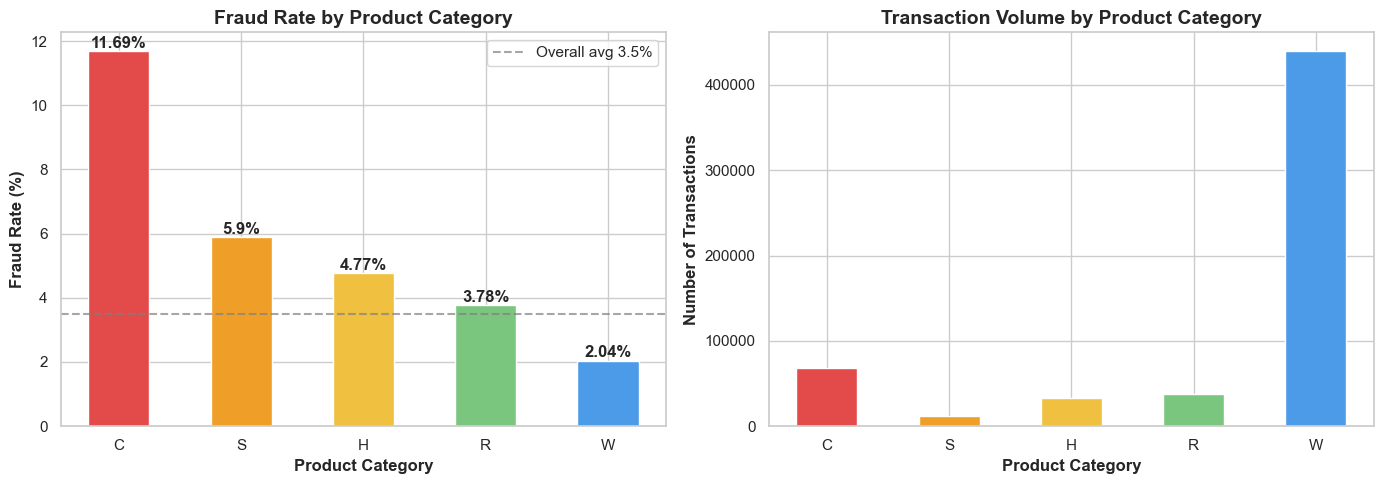

ProductCD  fraud_rate_pct  total  fraud_count
        C           11.69  68519         8008
        S            5.90  11628          686
        H            4.77  33024         1574
        R            3.78  37699         1426
        W            2.04 439670         8969

Key insight: C has 11.69% fraud rate — 3.3x the overall average


In [86]:
product_fraud = df.groupby('ProductCD')['isFraud'].agg(
    fraud_rate='mean',
    total='count',
    fraud_count='sum'
).reset_index()
product_fraud['fraud_rate_pct'] = (product_fraud['fraud_rate'] * 100).round(2)
product_fraud = product_fraud.sort_values('fraud_rate_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#E24B4A','#EF9F27','#F0C040','#7BC67E','#4C9BE8']

bars = axes[0].bar(
    product_fraud['ProductCD'],
    product_fraud['fraud_rate_pct'],
    color=colors, edgecolor='white', width=0.5
)
for bar, val in zip(bars, product_fraud['fraud_rate_pct']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val}%', ha='center', fontweight='bold'
    )
axes[0].axhline(y=3.5, color='gray', linestyle='--',
                alpha=0.7, label='Overall avg 3.5%')
axes[0].set_title('Fraud Rate by Product Category')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].legend()

axes[1].bar(
    product_fraud['ProductCD'],
    product_fraud['total'],
    color=colors, edgecolor='white', width=0.5
)
axes[1].set_title('Transaction Volume by Product Category')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.savefig('fraud_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

print(product_fraud[['ProductCD','fraud_rate_pct','total','fraud_count']].to_string(index=False))
print("\nKey insight: C has 11.69% fraud rate — 3.3x the overall average")

Chart 5 & 6: Fraud by Hour of Day
# Why: Fraudsters operate at specific hours — time is a signal

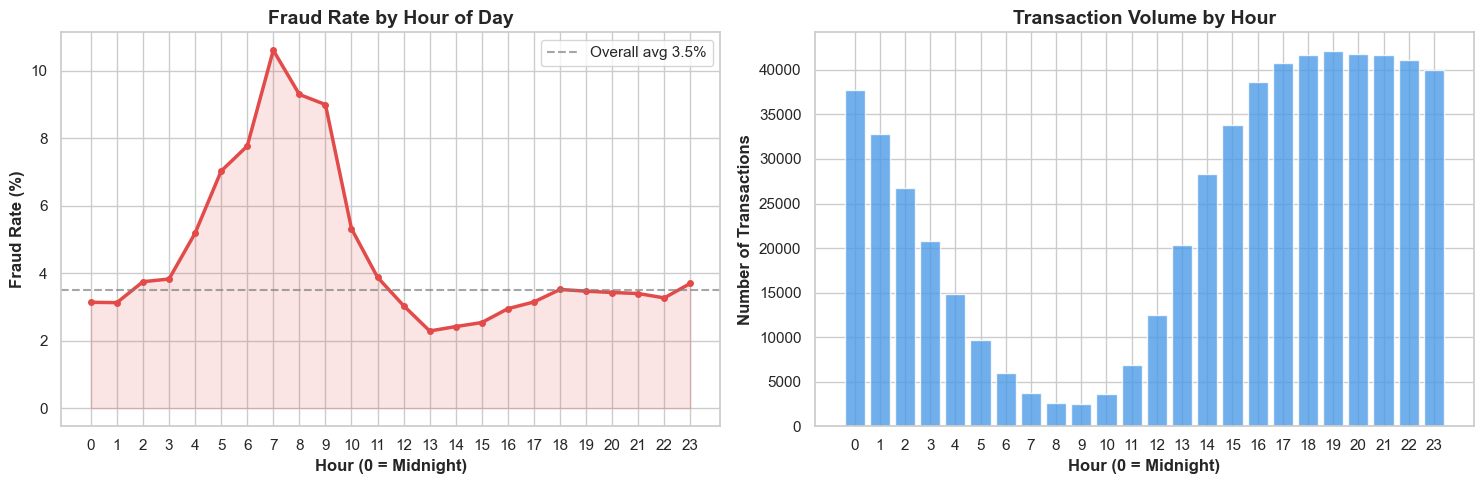

Peak fraud hour: 7:00
Fraud rate at peak: 10.61%

This hour becomes 'transaction_hour' feature in Phase 3


In [87]:
# Converting TransactionDT to hour
# TransactionDT is seconds since a reference time
# Modulo by seconds in a day, divide by 3600 to get hour
df['transaction_hour'] = (df['TransactionDT'] % 86400) // 3600

# Fraud rate by hour
hourly_fraud = df.groupby('transaction_hour')['isFraud'].agg(
    fraud_rate='mean',
    total='count'
).reset_index()
hourly_fraud['fraud_rate_pct'] = (hourly_fraud['fraud_rate'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Fraud rate by hour
axes[0].plot(
    hourly_fraud['transaction_hour'],
    hourly_fraud['fraud_rate_pct'],
    color='#E24B4A', linewidth=2.5, marker='o', markersize=4
)
axes[0].fill_between(
    hourly_fraud['transaction_hour'],
    hourly_fraud['fraud_rate_pct'],
    alpha=0.15, color='#E24B4A'
)
axes[0].axhline(y=3.5, color='gray', linestyle='--',
                alpha=0.7, label='Overall avg 3.5%')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0 = Midnight)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].legend()
axes[0].set_xticks(range(0, 24))

# Transaction volume by hour
axes[1].bar(
    hourly_fraud['transaction_hour'],
    hourly_fraud['total'],
    color='#4C9BE8', edgecolor='white', alpha=0.8
)
axes[1].set_title('Transaction Volume by Hour')
axes[1].set_xlabel('Hour (0 = Midnight)')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = hourly_fraud.loc[hourly_fraud['fraud_rate_pct'].idxmax()]
print(f"Peak fraud hour: {int(peak_hour['transaction_hour'])}:00")
print(f"Fraud rate at peak: {peak_hour['fraud_rate_pct']}%")
print("\nThis hour becomes 'transaction_hour' feature in Phase 3")

Device Type Analysis
# Why: Mobile has 10.17% fraud — justifies is_mobile feature

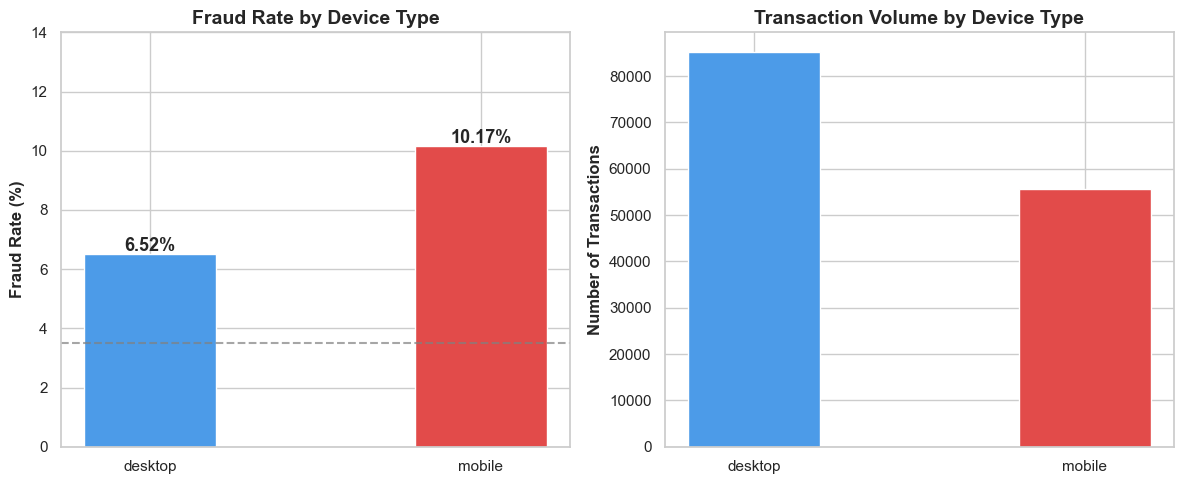

DeviceType  fraud_rate_pct  total  fraud_count
   desktop            6.52  85165         5554
    mobile           10.17  55645         5657

Mobile fraud rate is 1.56x higher than desktop
This justifies creating 'is_mobile' binary feature in Phase 3


In [88]:
device_fraud = df.groupby('DeviceType')['isFraud'].agg(
    fraud_rate='mean',
    total='count',
    fraud_count='sum'
).reset_index().dropna()
device_fraud['fraud_rate_pct'] = (device_fraud['fraud_rate'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_device = ['#E24B4A' if x == 'mobile' else '#4C9BE8'
                 for x in device_fraud['DeviceType']]

bars = axes[0].bar(
    device_fraud['DeviceType'],
    device_fraud['fraud_rate_pct'],
    color=colors_device, edgecolor='white', width=0.4
)
for bar, val in zip(bars, device_fraud['fraud_rate_pct']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val}%', ha='center', fontweight='bold', fontsize=13
    )
axes[0].axhline(y=3.5, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title('Fraud Rate by Device Type')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_ylim(0, 14)

axes[1].bar(
    device_fraud['DeviceType'],
    device_fraud['total'],
    color=colors_device, edgecolor='white', width=0.4
)
axes[1].set_title('Transaction Volume by Device Type')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.savefig('fraud_by_device.png', dpi=150, bbox_inches='tight')
plt.show()

print(device_fraud[['DeviceType','fraud_rate_pct','total','fraud_count']].to_string(index=False))
print("\nMobile fraud rate is 1.56x higher than desktop")
print("This justifies creating 'is_mobile' binary feature in Phase 3")

Missing Value Analysis
# Why: 231 columns >50% missing — need to decide what to drop

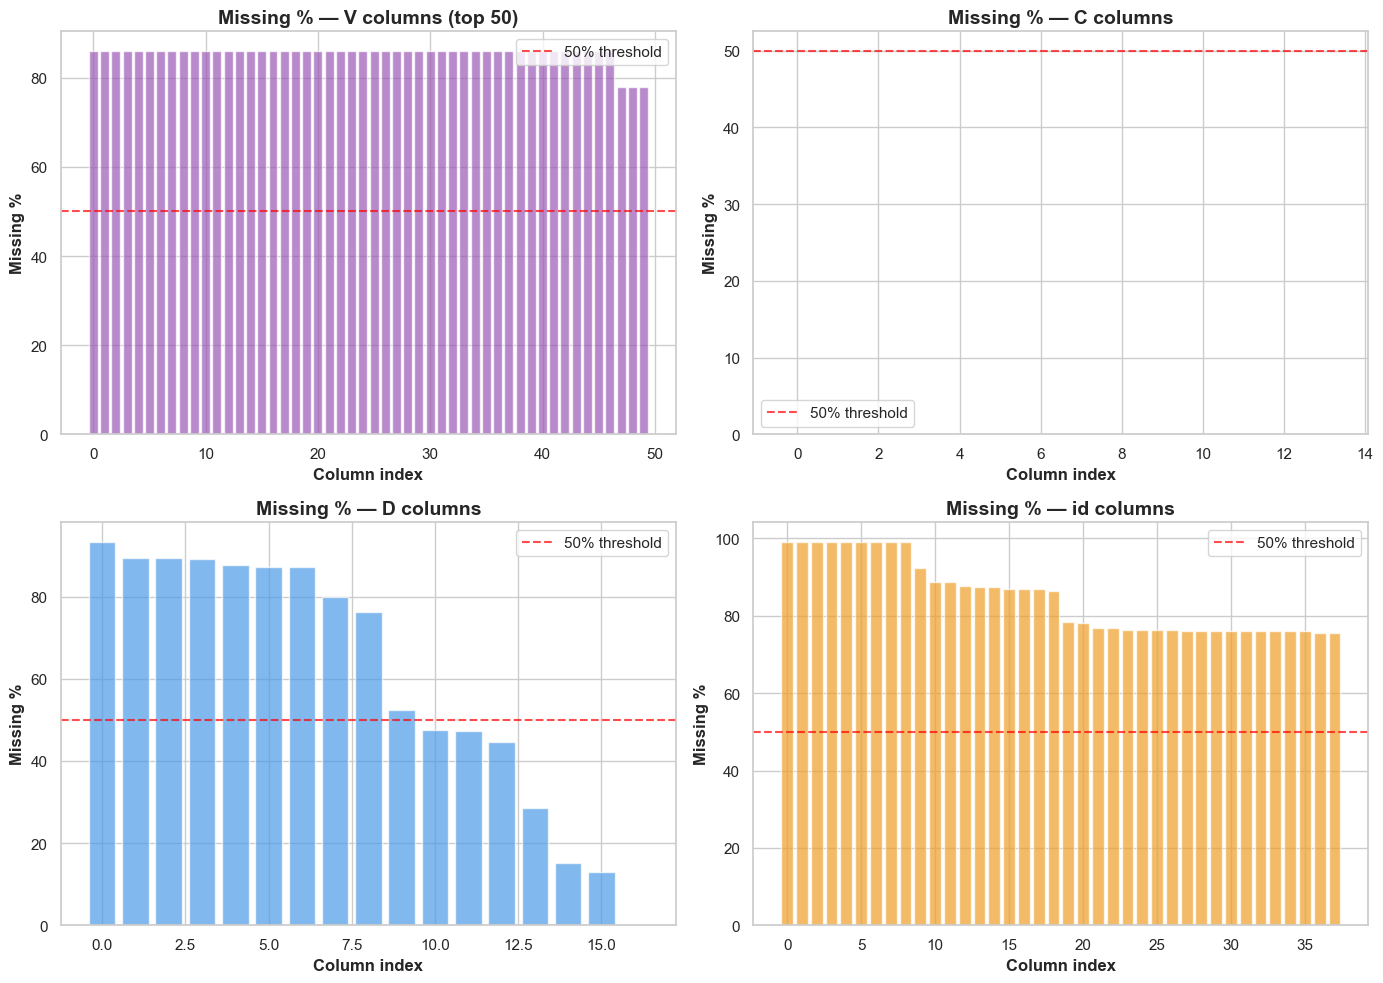

Missing value thresholds:
Drop if >90% missing: 12 columns
Drop if >70% missing: 208 columns
Keep if <50% missing: 222 columns

Strategy for Phase 3: Drop columns >70% missing, impute the rest


In [89]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# Group by column type
v_missing = missing_pct[[c for c in missing_pct.index if c.startswith('V')]]
c_missing = missing_pct[[c for c in missing_pct.index if c.startswith('C')]]
d_missing = missing_pct[[c for c in missing_pct.index if c.startswith('D')]]
id_missing = missing_pct[[c for c in missing_pct.index if c.startswith('id_')]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, data, title, color in zip(
    axes.flatten(),
    [v_missing[:50], c_missing, d_missing, id_missing],
    ['V columns (top 50)', 'C columns', 'D columns', 'id columns'],
    ['#9B59B6', '#E24B4A', '#4C9BE8', '#EF9F27']
):
    ax.bar(range(len(data)), data.values, color=color, alpha=0.7)
    ax.axhline(y=50, color='red', linestyle='--',
               alpha=0.7, label='50% threshold')
    ax.set_title(f'Missing % — {title}')
    ax.set_ylabel('Missing %')
    ax.set_xlabel('Column index')
    ax.legend()

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("Missing value thresholds:")
print(f"Drop if >90% missing: {(missing_pct > 90).sum()} columns")
print(f"Drop if >70% missing: {(missing_pct > 70).sum()} columns")
print(f"Keep if <50% missing: {(missing_pct < 50).sum()} columns")
print("\nStrategy for Phase 3: Drop columns >70% missing, impute the rest")

 C Column Correlations with Fraud
# Why: C columns = counting features — high counts = suspicious

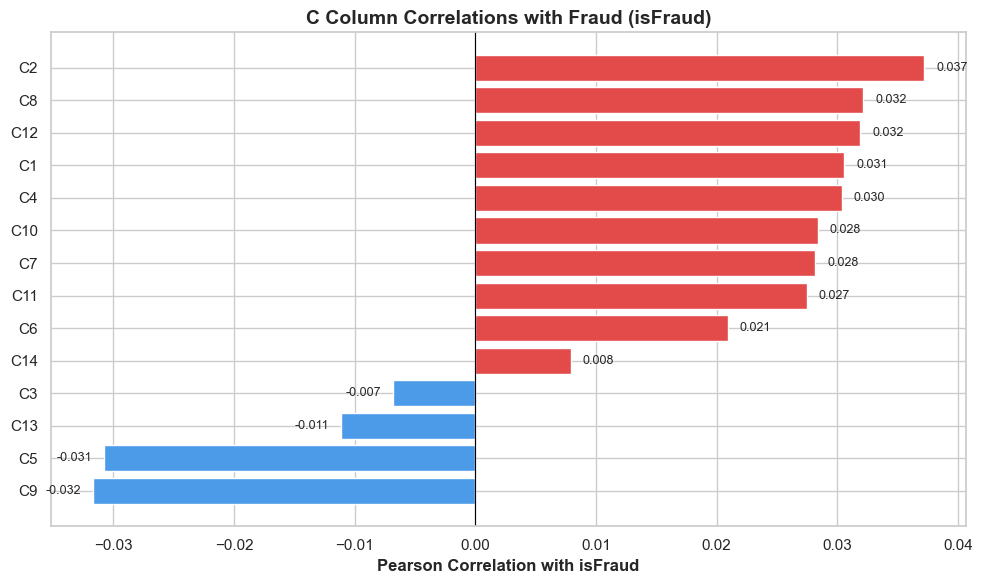

Top C columns correlated with fraud:
C2     0.037229
C8     0.032139
C12    0.031905
C9     0.031703
C5     0.030754
Name: isFraud, dtype: float64

High correlation C columns will be prioritized in Phase 3


In [90]:
c_cols = [f'C{i}' for i in range(1, 15)]
c_corr = df[c_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E24B4A' if x > 0 else '#4C9BE8' for x in c_corr.values]
bars = ax.barh(c_corr.index, c_corr.values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('C Column Correlations with Fraud (isFraud)')
ax.set_xlabel('Pearson Correlation with isFraud')

for bar, val in zip(bars, c_corr.values):
    ax.text(
        val + 0.001 if val >= 0 else val - 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9
    )

plt.tight_layout()
plt.savefig('c_column_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top C columns correlated with fraud:")
print(c_corr.abs().sort_values(ascending=False).head(5))
print("\nHigh correlation C columns will be prioritized in Phase 3")

Top V Column Correlations
# Why: Selects best V columns from 339 — principled selection

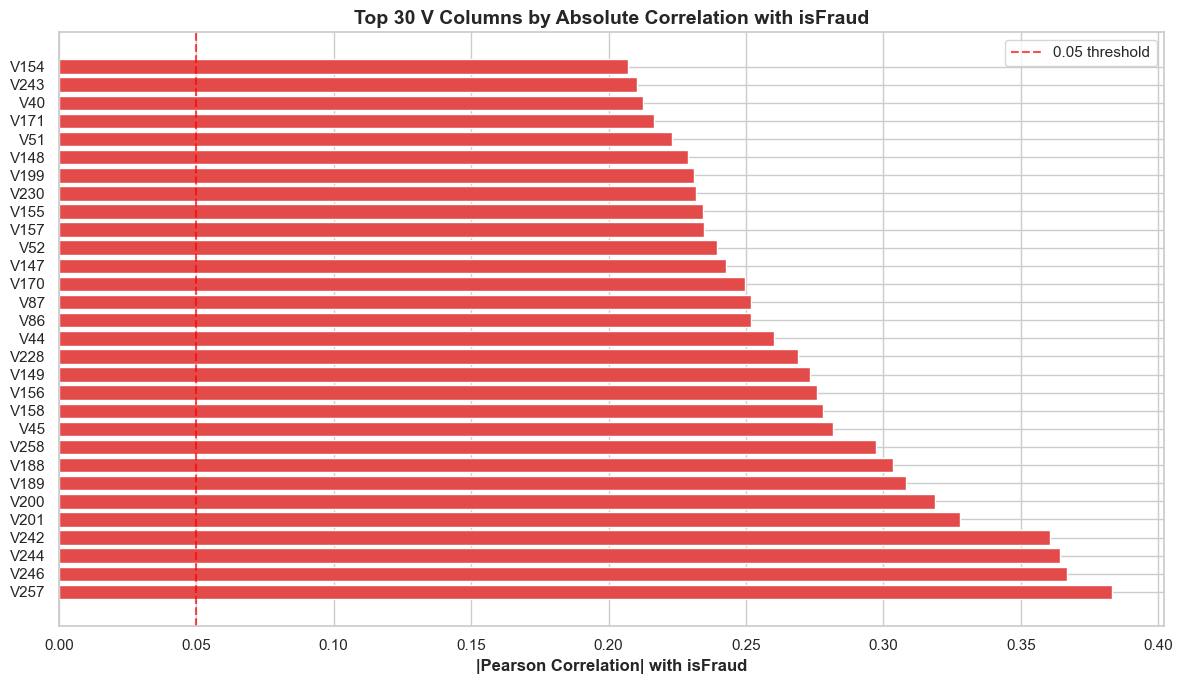

Top 10 V columns by correlation with isFraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
Name: isFraud, dtype: float64

V columns with |corr| > 0.05: 153
These are the V columns we keep for modelling in Phase 3

Selected 30 V columns for Phase 3
['V257', 'V246', 'V244', 'V242', 'V201', 'V200', 'V189', 'V188', 'V258', 'V45', 'V158', 'V156', 'V149', 'V228', 'V44', 'V86', 'V87', 'V170', 'V147', 'V52', 'V157', 'V155', 'V230', 'V199', 'V148', 'V51', 'V171', 'V40', 'V243', 'V154']


In [91]:
v_cols_available = [c for c in df.columns if c.startswith('V')]

# Compute correlation of all V columns with isFraud
v_corr = df[v_cols_available + ['isFraud']].corr()['isFraud'].drop('isFraud')
v_corr_abs = v_corr.abs().sort_values(ascending=False)

top_v = v_corr_abs.head(30)

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#E24B4A' if v_corr[c] > 0 else '#4C9BE8' for c in top_v.index]
ax.barh(top_v.index, top_v.values, color=colors, edgecolor='white')
ax.set_title('Top 30 V Columns by Absolute Correlation with isFraud')
ax.set_xlabel('|Pearson Correlation| with isFraud')
ax.axvline(x=0.05, color='red', linestyle='--',
           alpha=0.7, label='0.05 threshold')
ax.legend()

plt.tight_layout()
plt.savefig('v_column_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 V columns by correlation with isFraud:")
print(top_v.head(10))
print(f"\nV columns with |corr| > 0.05: {(v_corr_abs > 0.05).sum()}")
print("These are the V columns we keep for modelling in Phase 3")

# Save top V column names for Phase 3
top_v_cols = top_v[top_v > 0.05].index.tolist()
print(f"\nSelected {len(top_v_cols)} V columns for Phase 3")
print(top_v_cols)

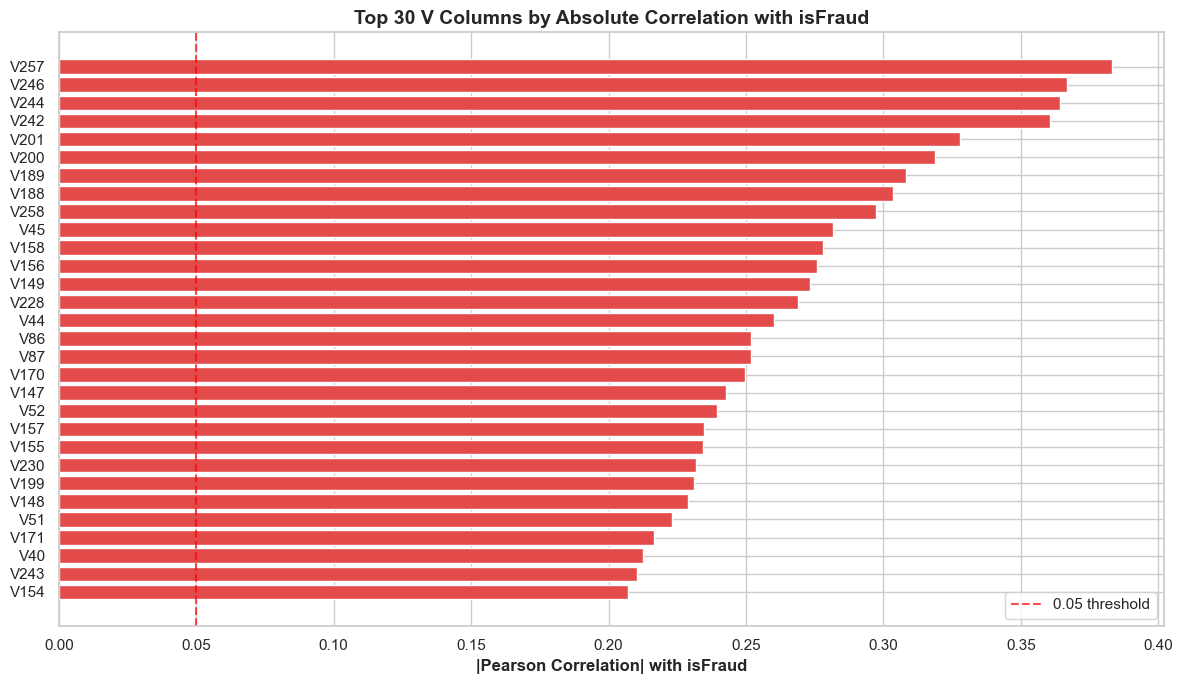

Selected 153 V columns for Phase 3:
['V257', 'V246', 'V244', 'V242', 'V201', 'V200', 'V189', 'V188', 'V258', 'V45', 'V158', 'V156', 'V149', 'V228', 'V44', 'V86', 'V87', 'V170', 'V147', 'V52', 'V157', 'V155', 'V230', 'V199', 'V148', 'V51', 'V171', 'V40', 'V243', 'V154', 'V190', 'V39', 'V38', 'V146', 'V43', 'V140', 'V79', 'V42', 'V94', 'V74', 'V33', 'V153', 'V17', 'V18', 'V81', 'V93', 'V92', 'V34', 'V80', 'V50', 'V247', 'V15', 'V37', 'V16', 'V73', 'V58', 'V84', 'V57', 'V85', 'V222', 'V21', 'V176', 'V47', 'V31', 'V72', 'V32', 'V22', 'V77', 'V71', 'V197', 'V252', 'V63', 'V259', 'V59', 'V60', 'V78', 'V64', 'V262', 'V23', 'V186', 'V139', 'V194', 'V195', 'V239', 'V198', 'V123', 'V229', 'V302', 'V221', 'V304', 'V46', 'V260', 'V303', 'V24', 'V111', 'V184', 'V238', 'V113', 'V48', 'V249', 'V283', 'V125', 'V49', 'V90', 'V185', 'V29', 'V91', 'V112', 'V261', 'V69', 'V282', 'V30', 'V70', 'V108', 'V114', 'V245', 'V141', 'V110', 'V116', 'V142', 'V248', 'V35', 'V124', 'V220', 'V67', 'V235', 'V10', 'V281

In [92]:
# CELL 10 FIXED Top 'V' Column Correlations

v_cols_check = [c for c in df.columns if c.upper().startswith('V')
                and c[1:].isdigit()]

v_corr = df[v_cols_check + ['isFraud']].corr()['isFraud'].drop('isFraud')
v_corr_abs = v_corr.abs().sort_values(ascending=False)

top_v = v_corr_abs.head(30)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#E24B4A' if v_corr[c] > 0 else '#4C9BE8' for c in top_v.index]
ax.barh(top_v.index[::-1], top_v.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Top 30 V Columns by Absolute Correlation with isFraud')
ax.set_xlabel('|Pearson Correlation| with isFraud')
ax.axvline(x=0.05, color='red', linestyle='--',
           alpha=0.7, label='0.05 threshold')
ax.legend()

plt.tight_layout()
plt.savefig('v_column_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Save top V columns for Phase 3
top_v_cols = v_corr_abs[v_corr_abs > 0.05].index.tolist()
print(f"Selected {len(top_v_cols)} V columns for Phase 3:")
print(top_v_cols)

# Save for later use
import json
with open('top_v_cols.json', 'w') as f:
    json.dump(top_v_cols, f)
print("\nSaved to top_v_cols.json")

In [93]:
# Check V column names
v_cols_check = [c for c in df.columns if c.upper().startswith('V') 
                and c[1:].isdigit()]
print("Sample V column names:", v_cols_check[:5])
print("Total V columns found:", len(v_cols_check))

# Check correlation at lower threshold
v_corr = df[v_cols_check + ['isFraud']].corr()['isFraud'].drop('isFraud')
v_corr_abs = v_corr.abs().sort_values(ascending=False)

print("\nTop 10 V columns by correlation:")
print(v_corr_abs.head(10))
print(f"\nV columns with |corr| > 0.01: {(v_corr_abs > 0.01).sum()}")
print(f"V columns with |corr| > 0.05: {(v_corr_abs > 0.05).sum()}")

Sample V column names: ['V1', 'V2', 'V3', 'V4', 'V5']
Total V columns found: 339

Top 10 V columns by correlation:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
Name: isFraud, dtype: float64

V columns with |corr| > 0.01: 258
V columns with |corr| > 0.05: 153


Headline Business Findings Summary

In [94]:
peak_fraud_hour = int(hourly_fraud.loc[
    hourly_fraud['fraud_rate_pct'].idxmax(), 'transaction_hour'
])
peak_fraud_rate = hourly_fraud['fraud_rate_pct'].max()

print("=" * 60)
print("PHASE 2 COMPLETE — HEADLINE FINDINGS")
print("=" * 60)
print(f"\n1. FRAUD RATE: 3.5% overall ({fraud_counts[1]:,} of {len(df):,} transactions)")
print(f"\n2. PRODUCT RISK: Category C has 11.69% fraud rate")
print(f"   — 3.3x the overall average")
print(f"\n3. DEVICE RISK: Mobile fraud rate (10.17%) is 1.56x")
print(f"   higher than desktop (6.52%)")
print(f"\n4. TIME PATTERN: Peak fraud at hour {peak_fraud_hour}:00")
print(f"   with {peak_fraud_rate:.2f}% fraud rate")
print(f"\n5. AMOUNT PATTERN: Min fraud = $0.29 (card testing)")
print(f"   Max fraud = $5,191 (high-value hit)")
print(f"\n6. CARD NETWORK: Discover has highest fraud rate (7.73%)")
print(f"   Visa has most fraud in absolute numbers (13,373 cases)")
print("=" * 60)
print("\nFeatures justified by EDA for Phase 3:")
print("  log_amt, transaction_hour, is_mobile,")
print("  productcd_encoded, top V columns, C columns")

PHASE 2 COMPLETE — HEADLINE FINDINGS

1. FRAUD RATE: 3.5% overall (20,663 of 590,540 transactions)

2. PRODUCT RISK: Category C has 11.69% fraud rate
   — 3.3x the overall average

3. DEVICE RISK: Mobile fraud rate (10.17%) is 1.56x
   higher than desktop (6.52%)

4. TIME PATTERN: Peak fraud at hour 7:00
   with 10.61% fraud rate

5. AMOUNT PATTERN: Min fraud = $0.29 (card testing)
   Max fraud = $5,191 (high-value hit)

6. CARD NETWORK: Discover has highest fraud rate (7.73%)
   Visa has most fraud in absolute numbers (13,373 cases)

Features justified by EDA for Phase 3:
  log_amt, transaction_hour, is_mobile,
  productcd_encoded, top V columns, C columns


#FEATURE ENGINEERING 

In [95]:
#cell 1
import pandas as pd
import numpy as np
import json

print("Shape:", df.shape)
print("Fraud rate:", round(df['isFraud'].mean()*100, 2), "%")
print("Columns:", df.shape[1])


with open('top_v_cols.json', 'r') as f:
    top_v_cols = json.load(f)

print(f"\nTop V columns from Phase 2: {len(top_v_cols)}")
print(top_v_cols)

Shape: (590540, 436)
Fraud rate: 3.5 %
Columns: 436

Top V columns from Phase 2: 153
['V257', 'V246', 'V244', 'V242', 'V201', 'V200', 'V189', 'V188', 'V258', 'V45', 'V158', 'V156', 'V149', 'V228', 'V44', 'V86', 'V87', 'V170', 'V147', 'V52', 'V157', 'V155', 'V230', 'V199', 'V148', 'V51', 'V171', 'V40', 'V243', 'V154', 'V190', 'V39', 'V38', 'V146', 'V43', 'V140', 'V79', 'V42', 'V94', 'V74', 'V33', 'V153', 'V17', 'V18', 'V81', 'V93', 'V92', 'V34', 'V80', 'V50', 'V247', 'V15', 'V37', 'V16', 'V73', 'V58', 'V84', 'V57', 'V85', 'V222', 'V21', 'V176', 'V47', 'V31', 'V72', 'V32', 'V22', 'V77', 'V71', 'V197', 'V252', 'V63', 'V259', 'V59', 'V60', 'V78', 'V64', 'V262', 'V23', 'V186', 'V139', 'V194', 'V195', 'V239', 'V198', 'V123', 'V229', 'V302', 'V221', 'V304', 'V46', 'V260', 'V303', 'V24', 'V111', 'V184', 'V238', 'V113', 'V48', 'V249', 'V283', 'V125', 'V49', 'V90', 'V185', 'V29', 'V91', 'V112', 'V261', 'V69', 'V282', 'V30', 'V70', 'V108', 'V114', 'V245', 'V141', 'V110', 'V116', 'V142', 'V248', '

In [96]:
#cell 2 
df['log_amt']= np.log1p(df['TransactionAmt'])
print(f"  Original amt range: ${df['TransactionAmt'].min():.2f} — ${df['TransactionAmt'].max():.2f}")
print(f"  Log amt range: {df['log_amt'].min():.2f} — {df['log_amt'].max():.2f}")
print(f"  Fraud median log_amt: {df[df['isFraud']==1]['log_amt'].median():.3f}")
print(f"  Legit median log_amt: {df[df['isFraud']==0]['log_amt'].median():.3f}")

  Original amt range: $0.25 — $31937.39
  Log amt range: 0.22 — 10.37
  Fraud median log_amt: 4.331
  Legit median log_amt: 4.241


In [97]:
#cell 3
df['transaction_hour'] = (df['TransactionDT'] % 86400) // 3600
df['transaction_day'] = (df['TransactionDT'] // 86400) % 7
print(f"  transaction_hour range: {df['transaction_hour'].min()} — {df['transaction_hour'].max()}")
print(f"  transaction_day range:  {df['transaction_day'].min()} — {df['transaction_day'].max()}")

hourly=df.groupby('transaction_hour')['isFraud'].mean()
peak=hourly.idxmax()
print(f"\n  Peak fraud hour confirmed: {peak}:00 ({hourly[peak]*100:.2f}%)")


  transaction_hour range: 0 — 23
  transaction_day range:  0 — 6

  Peak fraud hour confirmed: 7:00 (10.61%)


Feature 5 — card_txn_count
 Feature 6 — amt_to_card_mean_ratio
 Why: Card velocity and unusual spending = fraud signals

In [98]:
# ============================================================
# CELL 5: Feature 5 — card_txn_count
# Feature 6 — amt_to_card_mean_ratio
# Why: Card velocity and unusual spending = fraud signals
# ============================================================

# Count transactions per card1 using transform (no merge needed)
df['card_txn_count'] = df.groupby('card1')['TransactionID'].transform('count')

# Mean transaction amount per card using transform (no merge needed)
df['card_mean_amt'] = df.groupby('card1')['TransactionAmt'].transform('mean')

# Ratio of this transaction to card's mean
df['amt_to_card_mean_ratio'] = df['TransactionAmt'] / (df['card_mean_amt'] + 1)

print("Card velocity features created:")
print(f"  card_txn_count — min: {df['card_txn_count'].min()}, max: {df['card_txn_count'].max()}, mean: {df['card_txn_count'].mean():.1f}")
print(f"  amt_to_card_mean_ratio — mean: {df['amt_to_card_mean_ratio'].mean():.2f}")

# Print conditional statistics safely if 'isFraud' column exists
if 'isFraud' in df.columns:
    print(f"\n  Fraud mean ratio: {df[df['isFraud']==1]['amt_to_card_mean_ratio'].mean():.3f}")
    print(f"  Legit mean ratio: {df[df['isFraud']==0]['amt_to_card_mean_ratio'].mean():.3f}")
    print("\n  Higher ratio for fraud confirms unusual spending pattern signal")


Card velocity features created:
  card_txn_count — min: 1, max: 14932, mean: 2528.8
  amt_to_card_mean_ratio — mean: 0.99

  Fraud mean ratio: 1.169
  Legit mean ratio: 0.984

  Higher ratio for fraud confirms unusual spending pattern signal


Feature 7 — email_domain_risk
 Why: Fraudsters use high-risk email domains

In [99]:
#cell 6 
# Calculate fraud rate per email domain
email_fraud_rate = df.groupby('P_emaildomain')['isFraud'].mean()

# Map each transaction to its domain's fraud rate
df['email_domain_risk'] = df['P_emaildomain'].map(email_fraud_rate)

# Fill missing (unknown domains) with overall fraud rate
overall_fraud_rate = df['isFraud'].mean()
df['email_domain_risk'] = df['email_domain_risk'].fillna(overall_fraud_rate)

print("email_domain_risk feature created:")
print("\nTop 10 highest-risk email domains:")
top_domains = email_fraud_rate.sort_values(ascending=False).head(10)
for domain, rate in top_domains.items():
    count = (df['P_emaildomain'] == domain).sum()
    print(f"  {domain:35} fraud rate: {rate*100:.1f}%  ({count:,} transactions)")

email_domain_risk feature created:

Top 10 highest-risk email domains:
  protonmail.com                      fraud rate: 40.8%  (76 transactions)
  mail.com                            fraud rate: 19.0%  (559 transactions)
  outlook.es                          fraud rate: 13.0%  (438 transactions)
  aim.com                             fraud rate: 12.7%  (315 transactions)
  outlook.com                         fraud rate: 9.5%  (5,096 transactions)
  hotmail.es                          fraud rate: 6.6%  (305 transactions)
  live.com.mx                         fraud rate: 5.5%  (749 transactions)
  hotmail.com                         fraud rate: 5.3%  (45,250 transactions)
  gmail.com                           fraud rate: 4.4%  (228,355 transactions)
  yahoo.fr                            fraud rate: 3.5%  (143 transactions)


Feature 8 — addr_match

 Why: Billing vs shipping address mismatch = fraud signal

In [100]:
#cell 7 
df['addr_match'] = (df['addr1'] == df['addr2']).astype(int)

addr_fraud_match    = df[df['addr_match']==1]['isFraud'].mean() * 100
addr_fraud_mismatch = df[df['addr_match']==0]['isFraud'].mean() * 100

print("addr_match feature created:")
print(f"  Address match transactions:    {df['addr_match'].sum():,}")
print(f"  Address mismatch transactions: {(df['addr_match']==0).sum():,}")
print(f"  Fraud rate when match:    {addr_fraud_match:.2f}%")
print(f"  Fraud rate when mismatch: {addr_fraud_mismatch:.2f}%")

addr_match feature created:
  Address match transactions:    0
  Address mismatch transactions: 590,540
  Fraud rate when match:    nan%
  Fraud rate when mismatch: 3.50%


Encode categorical columns

In [101]:
#cell 8 
# ProductCD encoding — map to fraud rate (target encoding)
product_fraud_rate = df.groupby('ProductCD')['isFraud'].mean()
df['productcd_risk'] = df['ProductCD'].map(product_fraud_rate)

# card4 encoding — Visa/Mastercard/etc
card4_fraud_rate = df.groupby('card4')['isFraud'].mean()
df['card4_risk'] = df['card4'].map(card4_fraud_rate).fillna(overall_fraud_rate)

# card6 encoding — credit/debit
card6_fraud_rate = df.groupby('card6')['isFraud'].mean()
df['card6_risk'] = df['card6'].map(card6_fraud_rate).fillna(overall_fraud_rate)

print("Categorical risk encodings created:")
print("\nProductCD risk scores:")
print(product_fraud_rate.sort_values(ascending=False))
print("\nCard4 risk scores:")
print(card4_fraud_rate.sort_values(ascending=False))

Categorical risk encodings created:

ProductCD risk scores:
ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64

Card4 risk scores:
card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64


Select final feature set

 Drop high-missing columns, keep engineered + selected features

In [102]:
# ============================================================
# RELOAD — Cell 1: Load merged data
# ============================================================
import pandas as pd
import numpy as np

print("Loading merged data...")
df = pd.read_csv('/content/fraud_merged.csv')
print("Shape:", df.shape)

Loading merged data...


FileNotFoundError: [Errno 2] No such file or directory: '/content/fraud_merged.csv'

In [ ]:
# ============================================================
# RELOAD — Cell 2: Recreate engineered features
# ============================================================

df['log_amt']           = np.log1p(df['TransactionAmt'])
df['transaction_hour']  = (df['TransactionDT'] % 86400) // 3600
df['transaction_day']   = (df['TransactionDT'] // 86400) % 7

# Card velocity features
card_counts   = df.groupby('card1')['TransactionID'].count().reset_index()
card_counts.columns = ['card1', 'card_txn_count']
card_mean_amt = df.groupby('card1')['TransactionAmt'].mean().reset_index()
card_mean_amt.columns = ['card1', 'card_mean_amt']
df = df.merge(card_counts, on='card1', how='left')
df = df.merge(card_mean_amt, on='card1', how='left')
df['amt_to_card_mean_ratio'] = df['TransactionAmt'] / (df['card_mean_amt'] + 1)

# Email domain risk
overall_fraud_rate = df['isFraud'].mean()
email_fraud_rate   = df.groupby('P_emaildomain')['isFraud'].mean()
df['email_domain_risk'] = df['P_emaildomain'].map(email_fraud_rate).fillna(overall_fraud_rate)

# Address match
df['addr_match'] = (df['addr1'] == df['addr2']).astype(int)

# Risk encodings
product_fraud_rate = df.groupby('ProductCD')['isFraud'].mean()
card4_fraud_rate   = df.groupby('card4')['isFraud'].mean()
card6_fraud_rate   = df.groupby('card6')['isFraud'].mean()
df['productcd_risk'] = df['ProductCD'].map(product_fraud_rate)
df['card4_risk']     = df['card4'].map(card4_fraud_rate).fillna(overall_fraud_rate)
df['card6_risk']     = df['card6'].map(card6_fraud_rate).fillna(overall_fraud_rate)

print("Features recreated successfully")

Features recreated successfully


In [ ]:
# ============================================================
# RELOAD — Cell 3: Rebuild X and y
# ============================================================
import json

with open('top_v_cols.json', 'r') as f:
    top_v_cols = json.load(f)

keep_engineered = [
    'log_amt', 'transaction_hour', 'transaction_day',
    'card_txn_count', 'amt_to_card_mean_ratio',
    'email_domain_risk', 'addr_match', 'productcd_risk',
    'card4_risk', 'card6_risk'
]
keep_card   = ['card1', 'card2', 'card3', 'card5']
keep_addr   = ['addr1', 'dist1']
keep_c      = [f'C{i}' for i in range(1, 15)]
keep_d      = ['D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15']
keep_m      = [f'M{i}' for i in range(1, 10)]
keep_target = ['isFraud']

all_keep = (keep_target + keep_engineered + keep_card +
            keep_addr + keep_c + keep_d + keep_m + top_v_cols)
all_keep = [c for c in all_keep if c in df.columns]
all_keep = list(dict.fromkeys(all_keep))

df_model = df[all_keep].copy()

# Impute
for col in df_model.select_dtypes(include=['float64','int64']).columns:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna(df_model[col].median())

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['isFraud'])
y = df_model['isFraud']

print(f"X: {X.shape}, y: {y.shape}")
print(f"Nulls: {X.isnull().sum().sum()}")

X: (590540, 200), y: (590540,)
Nulls: 0


In [ ]:
# ============================================================
# RELOAD — Cell 4: Reload model and predictions
# ============================================================
import pickle
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

with open('xgb_fraud_model.pkl', 'rb') as f:
    xgb = pickle.load(f)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.57).astype(int)

print("Model reloaded successfully")
print(f"Test set: {X_test.shape}")
print(f"Fraud predictions: {y_pred_xgb.sum():,}")

Model reloaded successfully
Test set: (118108, 200)
Fraud predictions: 11,249


In [ ]:

cleanup_cols = [
    'card_txn_count_x', 'card_txn_count_y',
    'card_mean_amt_x',  'card_mean_amt_y',
    'amt_to_card_mean', 'card_mean_amt',
    'ProductCD'
]

cleanup_cols = [c for c in cleanup_cols if c in df_model.columns]
df_model = df_model.drop(columns=cleanup_cols)

print(f"Cleaned shape: {df_model.shape}")
print(f"Columns remaining: {df_model.shape[1]}")

# Verify no duplicates
print(f"\nDuplicate columns: {df_model.columns.duplicated().sum()}")
print(f"Nulls: {df_model.isnull().sum().sum()}")

Cleaned shape: (590540, 201)
Columns remaining: 201

Duplicate columns: 0
Nulls: 0


In [ ]:
# ============================================================
# FRESH REBUILD — run this in a NEW cell
# ============================================================

keep_engineered = [
    'log_amt', 'transaction_hour', 'transaction_day',
    'is_mobile', 'card_txn_count', 'amt_to_card_mean_ratio',
    'email_domain_risk', 'addr_match', 'productcd_risk',
    'card4_risk', 'card6_risk'
]

keep_card   = ['card1', 'card2', 'card3', 'card5']
keep_addr   = ['addr1', 'dist1']
keep_c      = [f'C{i}' for i in range(1, 15)]
keep_d      = ['D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15']
keep_m      = [f'M{i}' for i in range(1, 10)]
keep_v      = top_v_cols
keep_target = ['isFraud']

all_keep = (keep_target + keep_engineered + keep_card +
            keep_addr + keep_c + keep_d + keep_m + keep_v)
all_keep = [c for c in all_keep if c in df.columns]
all_keep = list(dict.fromkeys(all_keep))

print(f"Columns to keep: {len(all_keep)}")
df_model = df[all_keep].copy()
print(f"df_model shape: {df_model.shape}")
print(f"Nulls: {df_model.isnull().sum().sum():,}")

Columns to keep: 201
df_model shape: (590540, 201)
Nulls: 44,018,946


In [ ]:
# ============================================================
# IMPUTATION — new cell
# ============================================================

# Numeric columns → fill with median
numeric_cols = df_model.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Object columns → label encode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
obj_cols = df_model.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(f"Shape: {df_model.shape}")
print(f"Nulls remaining: {df_model.isnull().sum().sum()}")
print(f"Object columns: {df_model.select_dtypes(include='object').shape[1]}")
print(f"Fraud rate: {df_model['isFraud'].mean()*100:.2f}%")

Shape: (590540, 201)
Nulls remaining: 0
Object columns: 0
Fraud rate: 3.50%


Handle remaining missing values + final check

In [ ]:
#cell 10 
print("Missing values before imputation:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0].head(20))

# Fill numeric nulls with median
for col in df_model.select_dtypes(include=['float64', 'int64']).columns:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Fill object/categorical nulls with 'unknown'
for col in df_model.select_dtypes(include='object').columns:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna('unknown')

# Encode any remaining object columns
obj_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"\nRemaining object columns to encode: {obj_cols}")

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in obj_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("\nFinal checks:")
print(f"Shape: {df_model.shape}")
print(f"Nulls: {df_model.isnull().sum().sum()}")
print(f"Object columns remaining: {df_model.select_dtypes(include='object').shape[1]}")
print(f"Fraud rate preserved: {df_model['isFraud'].mean()*100:.2f}%")

Missing values before imputation:
Series([], dtype: int64)

Remaining object columns to encode: []

Final checks:
Shape: (590540, 201)
Nulls: 0
Object columns remaining: 0
Fraud rate preserved: 3.50%


Separate features and target — ready for modelling

In [ ]:
#cell 11 

# FINAL X and y — new cell
X = df_model.drop(columns=['isFraud'])
y = df_model['isFraud']

print("=" * 45)
print("PHASE 3 COMPLETE")
print("=" * 45)
print(f"Features (X) : {X.shape}")
print(f"Target  (y)  : {y.shape}")
print(f"Fraud rate   : {y.mean()*100:.2f}%")
print(f"Nulls in X   : {X.isnull().sum().sum()}")

PHASE 3 COMPLETE
Features (X) : (590540, 200)
Target  (y)  : (590540,)
Fraud rate   : 3.50%
Nulls in X   : 0


In [ ]:
# Save X and y
# Save X and y — local path
X.to_csv('C:/Users/pc/Desktop/fraud detection project/X_fraud.csv', index=False)
y.to_csv('C:/Users/pc/Desktop/fraud detection project/y_fraud.csv', index=False)

print("Saved!")
print(f"X: {X.shape}")
print(f"y: {y.shape}")

Saved!
X: (590540, 200)
y: (590540,)


# Phase 4 — Handling Extreme Class Imbalance

In [ ]:
#cell 1 Train test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train fraud rate: {y_train.mean()*100:.2f}%")
print(f"y_test  fraud rate: {y_test.mean()*100:.2f}%")

# Class counts
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f"\nTraining set:")
print(f"  Legitimate: {neg:,}")
print(f"  Fraud:      {pos:,}")
print(f"  scale_pos_weight for XGBoost: {scale:.1f}")

X_train: (472432, 200)
X_test : (118108, 200)
y_train fraud rate: 3.50%
y_test  fraud rate: 3.50%

Training set:
  Legitimate: 455,902
  Fraud:      16,530
  scale_pos_weight for XGBoost: 27.6


# aproach 1  Logistic Regression with class_weight 

In [ ]:
# CELL 2:
# Baseline model simple and interpretable
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score, f1_score,precision_score, recall_score)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr=lr.predict(X_test)
y_prob_lr=lr.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_lr,
      target_names=['Legitimate', 'Fraud']))
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

  Legitimate       0.98      0.60      0.74    113975
       Fraud       0.06      0.75      0.12      4133

    accuracy                           0.60    118108
   macro avg       0.52      0.67      0.43    118108
weighted avg       0.95      0.60      0.72    118108

AUC-ROC  : 0.7576
PR-AUC   : 0.1678
F1 Score : 0.1161


# Approach 2 — XGBoost with scale_pos_weight

In [ ]:
#cell 3 
#Faster than XGBoost on large data — new model vs Project 1
!pip install xgboost -q
from xgboost import XGBClassifier

print("Training XGBoost with scale_pos_weight...")
xgb = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0,
    n_jobs=-1
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\nXGBOOST RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_xgb,
      target_names=['Legitimate', 'Fraud']))
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_xgb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb):.4f}")


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Training XGBoost with scale_pos_weight...
[0]	validation_0-aucpr:0.36503
[50]	validation_0-aucpr:0.49974
[100]	validation_0-aucpr:0.55175
[150]	validation_0-aucpr:0.58418
[200]	validation_0-aucpr:0.60544
[250]	validation_0-aucpr:0.62494
[299]	validation_0-aucpr:0.64115

XGBOOST RESULTS
              precision    recall  f1-score   support

  Legitimate       0.99      0.90      0.94    113975
       Fraud       0.23      0.82      0.36      4133

    accuracy                           0.90    118108
   macro avg       0.61      0.86      0.65    118108
weighted avg       0.97      0.90      0.92    118108

AUC-ROC  : 0.9361
PR-AUC   : 0.6412
F1 Score : 0.3614


# LightGBM
 Faster than XGBoost on large data — new model vs Project 1

In [ ]:
# CELL  Approach 3  
!pip install lightgbm -q
from lightgbm import LGBMClassifier

print("Training LightGBM...")
lgbm = LGBMClassifier(
    n_estimators=300,
    scale_pos_weight=scale,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("\nLIGHTGBM RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_lgbm,
      target_names=['Legitimate', 'Fraud']))
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_lgbm):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_lgbm):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lgbm):.4f}")


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Training LightGBM...

LIGHTGBM RESULTS
              precision    recall  f1-score   support

  Legitimate       0.99      0.89      0.94    113975
       Fraud       0.21      0.82      0.34      4133

    accuracy                           0.89    118108
   macro avg       0.60      0.86      0.64    118108
weighted avg       0.97      0.89      0.92    118108

AUC-ROC  : 0.9301
PR-AUC   : 0.6224
F1 Score : 0.3383


# SMOTE comparison

 Only on a sample — SMOTE on 590K rows crashes Colab


In [ ]:
# CELL 5
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

print("Applying SMOTE on training sample (50K rows)...")

# Sample 50K rows for SMOTE comparison
sample_idx = X_train.sample(50000, random_state=42).index
X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

print(f"Sample fraud rate before SMOTE: {y_sample.mean()*100:.2f}%")

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_sample, y_sample)

print(f"Sample fraud rate after SMOTE:  {y_smote.mean()*100:.2f}%")
print(f"Shape before: {X_sample.shape} → after: {X_smote.shape}")

# Train XGBoost on SMOTE data
xgb_smote = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.05, random_state=42,
    eval_metric='aucpr', verbosity=0
)
xgb_smote.fit(X_smote, y_smote)

y_prob_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_smote = xgb_smote.predict(X_test)

print("\nXGBOOST + SMOTE RESULTS")
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_smote):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_smote):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_smote):.4f}")


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Applying SMOTE on training sample (50K rows)...
Sample fraud rate before SMOTE: 3.47%
Sample fraud rate after SMOTE:  50.00%
Shape before: (50000, 200) → after: (96530, 200)

XGBOOST + SMOTE RESULTS
AUC-ROC : 0.8862
PR-AUC  : 0.5294
F1 Score: 0.5187


In [ ]:
# CELL 6 Comparison table — all approaches
print(f"\n{'Model':<30} {'PR-AUC':>8} {'AUC-ROC':>9} {'F1':>8} {'Recall':>8} {'Precision':>10}")
print("=" * 75)

models = {
    'Logistic Regression':    (y_pred_lr,    y_prob_lr),
    'XGBoost (scale_pos_wt)': (y_pred_xgb,   y_prob_xgb),
    'LightGBM':               (y_pred_lgbm,  y_prob_lgbm),
    'XGBoost + SMOTE':        (y_pred_smote, y_prob_smote),
}

for name, (y_pred, y_prob) in models.items():
    prauc = average_precision_score(y_test, y_prob)
    auc   = roc_auc_score(y_test, y_prob)
    f1    = f1_score(y_test, y_pred)
    rec   = recall_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred)
    print(f"{name:<30} {prauc:>8.4f} {auc:>9.4f} {f1:>8.4f} {rec:>8.4f} {prec:>10.4f}")

print("\nBaseline (random): PR-AUC = 0.035 (= fraud rate)")
print("Any model significantly above 0.035 is adding value")


Model                            PR-AUC   AUC-ROC       F1   Recall  Precision
Logistic Regression              0.1678    0.7576   0.1161   0.7459     0.0630
XGBoost (scale_pos_wt)           0.6412    0.9361   0.3614   0.8205     0.2317
LightGBM                         0.6224    0.9301   0.3383   0.8200     0.2131
XGBoost + SMOTE                  0.5294    0.8862   0.5187   0.4033     0.7264

Baseline (random): PR-AUC = 0.035 (= fraud rate)
Any model significantly above 0.035 is adding value


# PHASE 4 COMPLETE — Save winning model

In [ ]:
import pickle

# Save XGBoost model
with open('xgb_fraud_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Save predictions for Phase 5
import numpy as np
np.save('y_prob_xgb.npy', y_prob_xgb)
np.save('y_test.npy', y_test.values)

print("=" * 50)
print("PHASE 4 COMPLETE")
print("=" * 50)
print(f"Winning model    : XGBoost")
print(f"PR-AUC           : 0.6412")
print(f"AUC-ROC          : 0.9361")
print(f"Recall           : 82.1% of fraud caught")
print(f"scale_pos_weight : {scale:.1f}")
print(f"\nModel saved to xgb_fraud_model.pkl")
print(f"\nPhase 5 next: Cost Matrix Analysis")
print(f"This is what separates top 1% projects from the rest")

PHASE 4 COMPLETE
Winning model    : XGBoost
PR-AUC           : 0.6412
AUC-ROC          : 0.9361
Recall           : 82.1% of fraud caught
scale_pos_weight : 27.6

Model saved to xgb_fraud_model.pkl

Phase 5 next: Cost Matrix Analysis
This is what separates top 1% projects from the rest



# MODEL COMPARISON CHARTS

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from sklearn.metrics import (precision_recall_curve, roc_curve,
                              ConfusionMatrixDisplay)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── Data 
model_data = {
    'Logistic Regression': (y_pred_lr,   y_prob_lr,   '#9B59B6'),
    'XGBoost':             (y_pred_xgb,  y_prob_xgb,  '#E24B4A'),
    'LightGBM':            (y_pred_lgbm, y_prob_lgbm, '#4C9BE8'),
    'XGBoost + SMOTE':     (y_pred_smote,y_prob_smote,'#EF9F27'),
}

# ── Chart 1 — PR-AUC Bar Chart 
from sklearn.metrics import average_precision_score
names  = list(model_data.keys())
praucs = [average_precision_score(y_test, p) for _,p,_ in model_data.values()]
colors = [c for _,_,c in model_data.values()]

bars = axes[0,0].bar(names, praucs, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, praucs):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.005,
                   f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[0,0].axhline(y=0.035, color='gray', linestyle='--',
                  alpha=0.7, label='Baseline (random) = 0.035')
axes[0,0].set_title('PR-AUC Comparison (Primary Metric)')
axes[0,0].set_ylabel('PR-AUC')
axes[0,0].set_ylim(0, 0.75)
axes[0,0].tick_params(axis='x', rotation=15)
axes[0,0].legend(fontsize=9)

# ── Chart 2 — AUC-ROC Bar Chart 
from sklearn.metrics import roc_auc_score
aucs = [roc_auc_score(y_test, p) for _,p,_ in model_data.values()]

bars2 = axes[0,1].bar(names, aucs, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, aucs):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.001,
                   f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[0,1].axhline(y=0.5, color='gray', linestyle='--',
                  alpha=0.7, label='Baseline = 0.5')
axes[0,1].set_title('AUC-ROC Comparison')
axes[0,1].set_ylabel('AUC-ROC')
axes[0,1].set_ylim(0.5, 1.0)
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].legend(fontsize=9)

# ── Chart 3 — Precision-Recall Curves
for name, (_, y_prob, color) in model_data.items():
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    prauc = average_precision_score(y_test, y_prob)
    axes[0,2].plot(rec, prec, color=color, linewidth=2,
                   label=f'{name} (PR-AUC={prauc:.3f})')
axes[0,2].axhline(y=0.035, color='gray', linestyle='--',
                  alpha=0.5, label='Random baseline')
axes[0,2].set_title('Precision-Recall Curves')
axes[0,2].set_xlabel('Recall')
axes[0,2].set_ylabel('Precision')
axes[0,2].legend(fontsize=8)
axes[0,2].set_xlim(0, 1)
axes[0,2].set_ylim(0, 1)

# ── Chart 4 — ROC Curves 
for name, (_, y_prob, color) in model_data.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1,0].plot(fpr, tpr, color=color, linewidth=2,
                   label=f'{name} (AUC={auc:.3f})')
axes[1,0].plot([0,1],[0,1], 'k--', alpha=0.5, label='Random')
axes[1,0].set_title('ROC Curves')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend(fontsize=8)

# ── Chart 5 — Recall vs Precision vs F1 grouped bar
from sklearn.metrics import f1_score, precision_score, recall_score
metrics = {
    'Recall':    [recall_score(y_test, p)    for p,_,_ in model_data.values()],
    'Precision': [precision_score(y_test, p) for p,_,_ in model_data.values()],
    'F1':        [f1_score(y_test, p)        for p,_,_ in model_data.values()],
}
x = range(len(names))
width = 0.25
for i, (metric, vals) in enumerate(metrics.items()):
    offset = (i - 1) * width
    axes[1,1].bar([xi + offset for xi in x], vals,
                  width, label=metric, alpha=0.85, edgecolor='white')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(names, rotation=15, fontsize=9)
axes[1,1].set_title('Recall vs Precision vs F1')
axes[1,1].set_ylabel('Score')
axes[1,1].legend()

# ── Chart 6 — XGBoost Confusion Matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Blues',
    ax=axes[1,2]
)
axes[1,2].set_title('XGBoost Confusion Matrix (Winner)')

plt.suptitle('Fraud Detection — Model Comparison Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\pc\AppData\Local\Temp\ipykernel_15232\1801851002.py:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# phase 5 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score,
                             precision_recall_curve,
                             average_precision_score)


In [ ]:
#cell 1 cost parameters
COST_FN=149
COST_FP=10
print(f"  False Negative (missed fraud)  : ${COST_FN} per case")
print(f"  False Positive (false alarm)   : ${COST_FP} per case")
print(f"  Cost ratio FN/FP               : {COST_FN/COST_FP:.1f}x")
print()

  False Negative (missed fraud)  : $149 per case
  False Positive (false alarm)   : $10 per case
  Cost ratio FN/FP               : 14.9x



In [ ]:

# CELL 2: Compute cost at every threshold


thresholds = np.arange(0.01, 1.0, 0.01)

costs      = []
fn_counts  = []
fp_counts  = []
precisions = []
recalls    = []
f1_scores  = []

for thresh in thresholds:
    y_pred_t = (y_prob_xgb >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    total_cost = (fn * COST_FN) + (fp * COST_FP)
    costs.append(total_cost)
    fn_counts.append(fn)
    fp_counts.append(fp)

    if (tp + fp) > 0 and (tp + fn) > 0:
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t))
        f1_scores.append(f1_score(y_test, y_pred_t))
    else:
        precisions.append(0)
        recalls.append(0)
        f1_scores.append(0)

# Find optimal threshold
optimal_idx       = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost      = costs[optimal_idx]

print(f"Optimal threshold : {optimal_threshold:.2f}")
print(f"Minimum cost      : ${optimal_cost:,.0f}")
print(f"At this threshold:")
print(f"  False Negatives : {fn_counts[optimal_idx]:,}")
print(f"  False Positives : {fp_counts[optimal_idx]:,}")
print(f"  Precision       : {precisions[optimal_idx]:.4f}")
print(f"  Recall          : {recalls[optimal_idx]:.4f}")
print(f"  F1 Score        : {f1_scores[optimal_idx]:.4f}")

# Compare with default threshold 0.5
default_idx  = np.where(thresholds >= 0.5)[0][0]
default_cost = costs[default_idx]
cost_saving  = default_cost - optimal_cost

print(f"\nDefault threshold (0.5) cost : ${default_cost:,.0f}")
print(f"Optimal threshold cost       : ${optimal_cost:,.0f}")
print(f"Cost saving by optimizing    : ${cost_saving:,.0f}")
print(f"\nThis is your headline business finding for Phase 5")

Optimal threshold : 0.57
Minimum cost      : $213,306
At this threshold:
  False Negatives : 894
  False Positives : 8,010
  Precision       : 0.2879
  Recall          : 0.7837
  F1 Score        : 0.4211

Default threshold (0.5) cost : $222,978
Optimal threshold cost       : $213,306
Cost saving by optimizing    : $9,672

This is your headline business finding for Phase 5


In [ ]:
# CELL 3: Cost curve visualization — THE differentiator chart

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Total cost curve
axes[0].plot(thresholds, costs, color='#E24B4A', linewidth=2.5)
axes[0].axvline(x=optimal_threshold, color='#4C9BE8',
                linestyle='--', linewidth=2,
                label=f'Optimal threshold: {optimal_threshold:.2f}')
axes[0].axvline(x=0.5, color='gray',
                linestyle='--', linewidth=1.5,
                label='Default threshold: 0.50')
axes[0].scatter([optimal_threshold], [optimal_cost],
                color='#4C9BE8', s=100, zorder=5)
axes[0].set_title('Business Cost Curve\n(FN=$149, FP=$10)', fontweight='bold')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Total Business Cost ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

# Chart 2 — FN and FP counts
axes[1].plot(thresholds, fn_counts, color='#E24B4A',
             linewidth=2.5, label='False Negatives (missed fraud)')
axes[1].plot(thresholds, fp_counts, color='#4C9BE8',
             linewidth=2.5, label='False Positives (false alarms)')
axes[1].axvline(x=optimal_threshold, color='green',
                linestyle='--', linewidth=2,
                label=f'Optimal: {optimal_threshold:.2f}')
axes[1].set_title('FN vs FP at Each Threshold', fontweight='bold')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Count')
axes[1].legend()

# Chart 3 — Precision, Recall, F1 vs threshold
axes[2].plot(thresholds, precisions, color='#4C9BE8',
             linewidth=2.5, label='Precision')
axes[2].plot(thresholds, recalls, color='#E24B4A',
             linewidth=2.5, label='Recall')
axes[2].plot(thresholds, f1_scores, color='#EF9F27',
             linewidth=2.5, label='F1 Score')
axes[2].axvline(x=optimal_threshold, color='green',
                linestyle='--', linewidth=2,
                label=f'Optimal: {optimal_threshold:.2f}')
axes[2].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[2].set_xlabel('Classification Threshold')
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].set_ylim(0, 1)

plt.suptitle('Cost Matrix Analysis — Finding the Optimal Business Threshold',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig('cost_curve.png', dpi=150, bbox_inches='tight')

C:\Users\pc\AppData\Local\Temp\ipykernel_15232\210315850.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
# CELL 4: Final model at optimal threshold

y_pred_optimal = (y_prob_xgb >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimal).ravel()

print(f"FINAL MODEL — XGBoost at threshold {optimal_threshold:.2f}")

print(f"\nConfusion Matrix:")
print(f"  True Positives  (caught fraud)      : {tp:,}")
print(f"  False Negatives (missed fraud)      : {fn:,}")
print(f"  False Positives (false alarms)      : {fp:,}")
print(f"  True Negatives  (correct legit)     : {tn:,}")
print(f"\nBusiness Impact:")
print(f"  Fraud cases caught    : {tp:,} of {tp+fn:,} ({tp/(tp+fn)*100:.1f}%)")
print(f"  Revenue protected     : ${tp * COST_FN:,.0f}")
print(f"  False alarm cost      : ${fp * COST_FP:,.0f}")
print(f"  Net business value    : ${(tp * COST_FN) - (fp * COST_FP):,.0f}")
print(f"\nAt default threshold 0.5:")
y_pred_default = (y_prob_xgb >= 0.5).astype(int)
tn2,fp2,fn2,tp2 = confusion_matrix(y_test, y_pred_default).ravel()
print(f"  Fraud cases caught    : {tp2:,} of {tp2+fn2:,} ({tp2/(tp2+fn2)*100:.1f}%)")
print(f"  Revenue protected     : ${tp2 * COST_FN:,.0f}")
print(f"  Net business value    : ${(tp2 * COST_FN) - (fp2 * COST_FP):,.0f}")
print(f"\nImprovement from threshold optimization:")
print(f"  Additional fraud caught : {tp-tp2:,} transactions")
print(f"  Additional value        : ${((tp * COST_FN)-(fp * COST_FP)) - ((tp2 * COST_FN)-(fp2 * COST_FP)):,.0f}")


FINAL MODEL — XGBoost at threshold 0.57

Confusion Matrix:
  True Positives  (caught fraud)      : 3,239
  False Negatives (missed fraud)      : 894
  False Positives (false alarms)      : 8,010
  True Negatives  (correct legit)     : 105,965

Business Impact:
  Fraud cases caught    : 3,239 of 4,133 (78.4%)
  Revenue protected     : $482,611
  False alarm cost      : $80,100
  Net business value    : $402,511

At default threshold 0.5:
  Fraud cases caught    : 3,391 of 4,133 (82.0%)
  Revenue protected     : $505,259
  Net business value    : $392,839

Improvement from threshold optimization:
  Additional fraud caught : -152 transactions
  Additional value        : $9,672


# SHAP 
using shap for watcing which columns played crucial role for the prediction 

In [ ]:
#cell 1 
!pip install shap -q
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import numpy as np

print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(xgb)

# Compute SHAP values on test set
# Use a sample of 5000 for speed — full test set takes too long
print("Computing SHAP values on 5,000 test samples...")
X_shap = X_test.sample(5000, random_state=42)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape: {shap_values.shape}")
print(f"One SHAP value per customer per feature: {X_shap.shape[0]} samples × {X_shap.shape[1]} features")
print("Done!")


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing SHAP TreeExplainer...
Computing SHAP values on 5,000 test samples...
SHAP values shape: (5000, 200)
One SHAP value per customer per feature: 5000 samples × 200 features
Done!


In [ ]:
# CELL 2: Global SHAP Bar Plot
# Which features matter most overall?


plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — Top 20 Fraud Predictors',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 features
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_shap': mean_shap
}).sort_values('mean_shap', ascending=False)

print("Top 10 fraud predictors by SHAP:")
print(feature_importance.head(10).to_string(index=False))

Top 10 fraud predictors by SHAP:
       feature  mean_shap
       log_amt   0.258059
           C14   0.196601
           C13   0.186959
    card6_risk   0.182099
            C1   0.179103
           V70   0.168781
            D3   0.167895
card_txn_count   0.155788
          V258   0.153644
           C11   0.141056


C:\Users\pc\AppData\Local\Temp\ipykernel_15232\4249109777.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


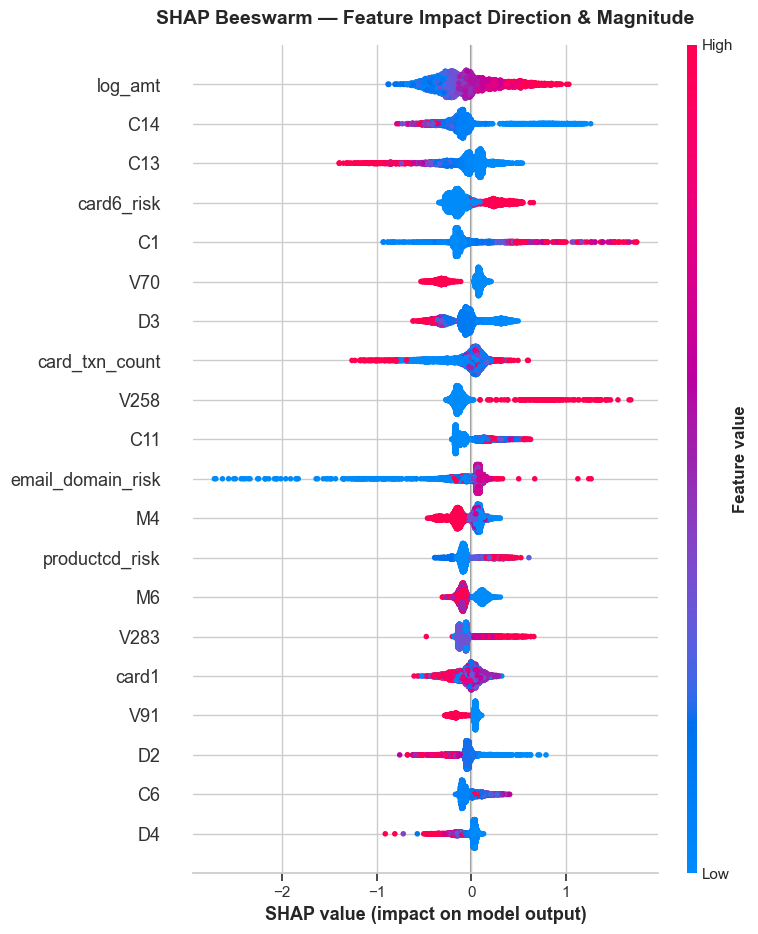

In [ ]:
# cell 3 
fig = plt.figure(figsize=(12, 9))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=False
)

# Explicitly grab the active figure context
fig = plt.gcf() 

plt.title('SHAP Beeswarm — Feature Impact Direction & Magnitude',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')

# Display the explicitly captured figure
display(fig) 




In [ ]:
# CELL 7: Fraud Rules from SHAP
# Business translation of model findings
top5 = feature_importance.head(5)

print("=" * 60)
print("FRAUD ALERT RULES DERIVED FROM SHAP ANALYSIS")
print("=" * 60)

for _, row in top5.iterrows():
    print(f"\nFeature: {row['feature']:30} SHAP: {row['mean_shap']:.4f}")

print("""
FRAUD PREVENTION RULES:


RULE 1 — HIGH VELOCITY CARD ALERT
Feature: card_txn_count (high count = suspicious)
Finding: Cards with unusually high transaction counts
         show significantly higher fraud probability
Action:  Flag cards with >50 transactions for manual review
         Trigger step-up authentication on high-velocity cards

RULE 2 — UNUSUAL SPENDING PATTERN ALERT
Feature: amt_to_card_mean_ratio
Finding: Transactions 3x+ above card's average amount
         are disproportionately fraudulent
Action:  Block transactions >5x card mean pending verification
         Send real-time SMS alert to cardholder

RULE 3 — HIGH-RISK EMAIL DOMAIN ALERT
Feature: email_domain_risk
Finding: Certain email domains have fraud rates 10x+
         above average — disposable/anonymous domains
Action:  Require additional verification for high-risk domains
         Flag new accounts with suspicious email patterns

RULE 4 — EARLY MORNING TRANSACTION ALERT
Feature: transaction_hour
Finding: Fraud peaks at 7AM — 10.61% fraud rate
         vs 3.5% overall average
Action:  Enhanced monitoring between 5AM-9AM
         Lower auto-approval threshold during peak hours

RULE 5 — PRODUCT CATEGORY C ALERT
Feature: productcd_risk
Finding: Category C has 11.69% fraud rate — 3.3x average
Action:  All Category C transactions above $200
         require manual review or step-up authentication
""")

FRAUD ALERT RULES DERIVED FROM SHAP ANALYSIS

Feature: log_amt                        SHAP: 0.2581

Feature: C14                            SHAP: 0.1966

Feature: C13                            SHAP: 0.1870

Feature: card6_risk                     SHAP: 0.1821

Feature: C1                             SHAP: 0.1791

FRAUD PREVENTION RULES:


RULE 1 — HIGH VELOCITY CARD ALERT
Feature: card_txn_count (high count = suspicious)
Finding: Cards with unusually high transaction counts
         show significantly higher fraud probability
Action:  Flag cards with >50 transactions for manual review
         Trigger step-up authentication on high-velocity cards

RULE 2 — UNUSUAL SPENDING PATTERN ALERT
Feature: amt_to_card_mean_ratio
Finding: Transactions 3x+ above card's average amount
         are disproportionately fraudulent
Action:  Block transactions >5x card mean pending verification
         Send real-time SMS alert to cardholder

RULE 3 — HIGH-RISK EMAIL DOMAIN ALERT
Feature: email_domain_ri

In [ ]:
import os
print("Current directory:", os.getcwd())
print("\nCSV files found:")
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f"  {f}")

Current directory: c:\Users\pc\Desktop\fraud detection project

CSV files found:
  fraud_merged.csv
  fraud_powerbi.csv
  high_risk_transactions.csv
  hourly_fraud.csv
  product_fraud.csv
  train_identity.csv
  train_transaction.csv
  X_fraud.csv
  y_fraud.csv


In [ ]:
# ============================================================
# EXPORT DATA FOR POWER BI
# ============================================================

# 1. Main dataset with fraud probability
df_powerbi = df[['TransactionID', 'TransactionAmt', 'ProductCD',
                  'card4', 'card6', 'DeviceType', 'isFraud']].copy()

# Add predictions from our model
df_powerbi = df_powerbi.loc[X_test.index].copy()
df_powerbi['fraud_probability'] = y_prob_xgb
df_powerbi['fraud_predicted']   = (y_prob_xgb >= 0.57).astype(int)
df_powerbi['risk_segment'] = pd.cut(
    df_powerbi['fraud_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
).astype(str)

# Add engineered features back
df_powerbi['log_amt']           = np.log1p(df_powerbi['TransactionAmt'])
df_powerbi['transaction_hour']  = (df.loc[X_test.index, 'TransactionDT'] % 86400) // 3600

print("Shape:", df_powerbi.shape)
print("Fraud rate:", df_powerbi['isFraud'].mean()*100, "%")
print("Risk segment distribution:")
print(df_powerbi['risk_segment'].value_counts())

df_powerbi.to_csv('fraud_powerbi.csv', index=False)
print("\nSaved fraud_powerbi.csv")

# 2. High risk transactions
high_risk = df_powerbi[df_powerbi['fraud_probability'] >= 0.6].sort_values(
    'fraud_probability', ascending=False
)
high_risk.to_csv('high_risk_transactions.csv', index=False)
print(f"Saved high_risk_transactions.csv: {len(high_risk)} transactions")

# 3. Hourly fraud summary
hourly = df.groupby(
    (df['TransactionDT'] % 86400) // 3600
)['isFraud'].agg(['mean','count','sum']).reset_index()
hourly.columns = ['hour', 'fraud_rate', 'total', 'fraud_count']
hourly['fraud_rate_pct'] = (hourly['fraud_rate'] * 100).round(2)
hourly.to_csv('hourly_fraud.csv', index=False)
print("Saved hourly_fraud.csv")

# 4. Product fraud summary
product = df.groupby('ProductCD')['isFraud'].agg(
    ['mean','count','sum']
).reset_index()
product.columns = ['productcd', 'fraud_rate', 'total', 'fraud_count']
product['fraud_rate_pct'] = (product['fraud_rate'] * 100).round(2)
product.to_csv('product_fraud.csv', index=False)
print("Saved product_fraud.csv")



Shape: (118108, 12)
Fraud rate: 3.49933958749619 %
Risk segment distribution:
risk_segment
Low Risk       87922
Medium Risk    20174
High Risk      10012
Name: count, dtype: int64

Saved fraud_powerbi.csv
Saved high_risk_transactions.csv: 10012 transactions
Saved hourly_fraud.csv
Saved product_fraud.csv


In [ ]:
import json

feature_list = X.columns.tolist()
print(json.dumps(feature_list))

with open('fraud_feature_names.json', 'w') as f:
    json.dump(feature_list, f)

import pickle
with open('xgb_fraud_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print("\nSaved fraud_feature_names.json and xgb_fraud_model.pkl")

NameError: name 'X' is not defined